# Deep Learning Lab Assignment: Advanced CIFAR-10 Image Classification
### Course: Advanced Machine Learning / Computer Vision
**Objective:** Build, fine-tune, optimize, and evaluate a Deep Convolutional Neural Network on the CIFAR-10 dataset to approach state-of-the-art academic benchmarks.

---

## Step 1: Environmental Setup & Dependencies
We begin by downloading standard evaluation packages and verifying CUDA runtime availability to accelerate training via PyTorch.

In [ ]:
!pip install scikit-learn matplotlib seaborn tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# random seeds
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing assignment workflow on hardware target device: {device}")

Executing assignment workflow on hardware target device: cuda


## Step 2: Strategic Data Augmentation & Normalization
To outperform simple configurations, we use explicit pixel normalizations calculated directly from the CIFAR channel stats, along with automated Random Erasing (`RandomErasing`) and Random Affine Transformations to safeguard our deep model from overfitting.

In [2]:
# Establish unique data pipeline augmentations distinct from baseline comparisons
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                  # Scale up image dimensionality for pre-trained ImageNet structures
    transforms.RandomHorizontalFlip(p=0.5),          # Random mirroring for orientation invariance
    transforms.RandomRotation(15),                   # Slight orientation variations to handle camera adjustments
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translation variance
    transforms.ToTensor(),                           # Convert image matrix representation to float tensor
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616]), # Empirical channel values for CIFAR-10 distribution
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), value='random') # Introduce occlusions to reinforce robustness
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),                  # Keep evaluation validation inputs identically scaled
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# Download and construct standard train/test structures directly from PyTorch hub repositories
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Reserve 10% explicit Validation split for precise validation assessment monitoring
train_val_ratio = 0.9
train_len = int(len(full_train_dataset) * train_val_ratio)
val_len = len(full_train_dataset) - train_len

train_dataset, val_dataset = random_split(full_train_dataset, [train_len, val_len])

# Note: Override validation transform rules to drop train data alterations during testing metrics checks
val_dataset.dataset.transform = test_transform

# Instantiate DataLoader constructs with high efficiency thread caching workers
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Partition Splits Summary: Train Samples: {len(train_dataset)} | Val Samples: {len(val_dataset)} | Test Samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:06<00:00, 27.5MB/s]


Partition Splits Summary: Train Samples: 45000 | Val Samples: 5000 | Test Samples: 10000


## Step 3: Architecture Definition (ResNet34 Deep Baseline)
To make our code distinct from basic configurations (like ResNet18 or basic VGG models), we select **ResNet34**. We adjust the final classification layer (`fc`) to match our 10 targeted image classes, while leaving the entire backbone network open for backpropagation tuning adjustments.

In [3]:
print("[Architecture Setup] Initializing customized ResNet34 pipeline backbone with ImageNet pretrained feature extraction layers...")
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Modify fully connected terminal layer output to handle 10 targets mapping space
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),                                # Add dropout step to improve regularization metrics
    nn.Linear(in_features, len(classes))              # Map hidden vectors space out directly to 10 class distributions
)

# Ship weights model out to our GPU hardware target instance
model = model.to(device)

# Verify all parameter configurations remain trainable for thorough unconstrained fine-tuning iterations
for name, param in model.named_parameters():
    param.requires_grad = True

print("Model network configuration loaded into execution target memory successfully.")

[Architecture Setup] Initializing customized ResNet34 pipeline backbone with ImageNet pretrained feature extraction layers...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 205MB/s]


Model network configuration loaded into execution target memory successfully.


## Step 4: Optimization, Regularization and Learning Rate Control Strategy
Instead of standard Adam or basic SGD steps, we introduce **AdamW**. This decouples weight decay loss tracking to keep gradient checks regularized. We couple it with a **CosineAnnealingLR** scheduling routine to prevent local minima plateaus.

In [4]:
# Setup explicit loss calculation metrics
criterion = nn.CrossEntropyLoss()

# Define modern decoupled weight decay AdamW architecture execution optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Implement smooth Cosine Annealing dynamic decay schedule across epoch loops
epochs = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
print("Advanced optimization tracking tools and schedulers initialized successfully.")

Advanced optimization tracking tools and schedulers initialized successfully.


## Step 5: Iterative Training and Tracking Execution Engine
This engine processes training batches through forward/backward validation checks, prints progress metrics dynamically per epoch, and runs defensive checks to ensure the highest-accuracy checkpoint state weights are saved.

In [5]:
# Track training performance histories over the epochs loop
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}
best_val_accuracy = 0.0

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    print(f"\n--- Starting Epoch Sequence Group {epoch+1}/{epochs} ---")
    for batch_imgs, batch_labels in tqdm(train_loader, desc="Training Iterations"):
        batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

        # Reset gradients state
        optimizer.zero_grad()

        # Forward propagation pass check
        outputs = model(batch_imgs)
        loss = criterion(outputs, batch_labels)

        # Backward gradient propagation adjustment pass
        loss.backward()
        optimizer.step()

        # Accumulate metrics tracking data logs
        running_loss += loss.item() * batch_imgs.size(0)
        _, predictions = torch.max(outputs, 1)
        train_total += batch_labels.size(0)
        train_correct += (predictions == batch_labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = (train_correct / train_total) * 100

    # --- Validation Verification Evaluation Phase ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for val_imgs, val_labels in tqdm(val_loader, desc="Validation Monitoring Checks"):
            val_imgs, val_labels = val_imgs.to(device), val_labels.to(device)
            val_outputs = model(val_imgs)
            val_loss_calc = criterion(val_outputs, val_labels)

            running_val_loss += val_loss_calc.item() * val_imgs.size(0)
            _, val_preds = torch.max(val_outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (val_preds == val_labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = (val_correct / val_total) * 100

    # Advance the learning rate decay schedule
    scheduler.step()

    # Cache history traces
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch Stats: [Loss] Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f} [Accuracy] Train: {epoch_train_acc:.2f}% | Val: {epoch_val_acc:.2f}%")

    # Rule 6 Implementation: Intercept checkpoint updates if top validation accuracy is surpassed
    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        print(f"Validation performance improvement spotted! Storing model parameters to: optimized_cifar10_model.pth")
        torch.save(model.state_dict(), 'optimized_cifar10_model.pth')


--- Starting Epoch Sequence Group 1/15 ---


Validation Monitoring Checks: 100%|██████████| 79/79 [00:11<00:00,  7.05it/s]


Epoch Stats: [Loss] Train: 0.3079 | Val: 0.1875 [Accuracy] Train: 89.81% | Val: 93.74%
Validation performance improvement spotted! Storing model parameters to: optimized_cifar10_model.pth

--- Starting Epoch Sequence Group 2/15 ---


Validation Monitoring Checks: 100%|██████████| 79/79 [00:10<00:00,  7.55it/s]


Epoch Stats: [Loss] Train: 0.1106 | Val: 0.1590 [Accuracy] Train: 96.38% | Val: 94.70%
Validation performance improvement spotted! Storing model parameters to: optimized_cifar10_model.pth

--- Starting Epoch Sequence Group 3/15 ---


...

Epoch Stats: [Loss] Train: 0.0005 | Val: 0.1413 [Accuracy] Train: 99.99% | Val: 96.80%
Validation performance improvement spotted! Storing model parameters to: optimized_cifar10_model.pth

--- Starting Epoch Sequence Group 14/15 ---


Validation Monitoring Checks: 100%|██████████| 79/79 [00:10<00:00,  7.49it/s]


Epoch Stats: [Loss] Train: 0.0006 | Val: 0.1427 [Accuracy] Train: 99.99% | Val: 96.66%

--- Starting Epoch Sequence Group 15/15 ---


Validation Monitoring Checks: 100%|██████████| 79/79 [00:10<00:00,  7.41it/s]

Epoch Stats: [Loss] Train: 0.0003 | Val: 0.1427 [Accuracy] Train: 100.00% | Val: 96.68%


## Step 6: Diagnostic Visualization Reporting Charts
Here, we generate loss and accuracy performance curves over the training history timeline to verify proper gradient updates and identify any overfitting trends.

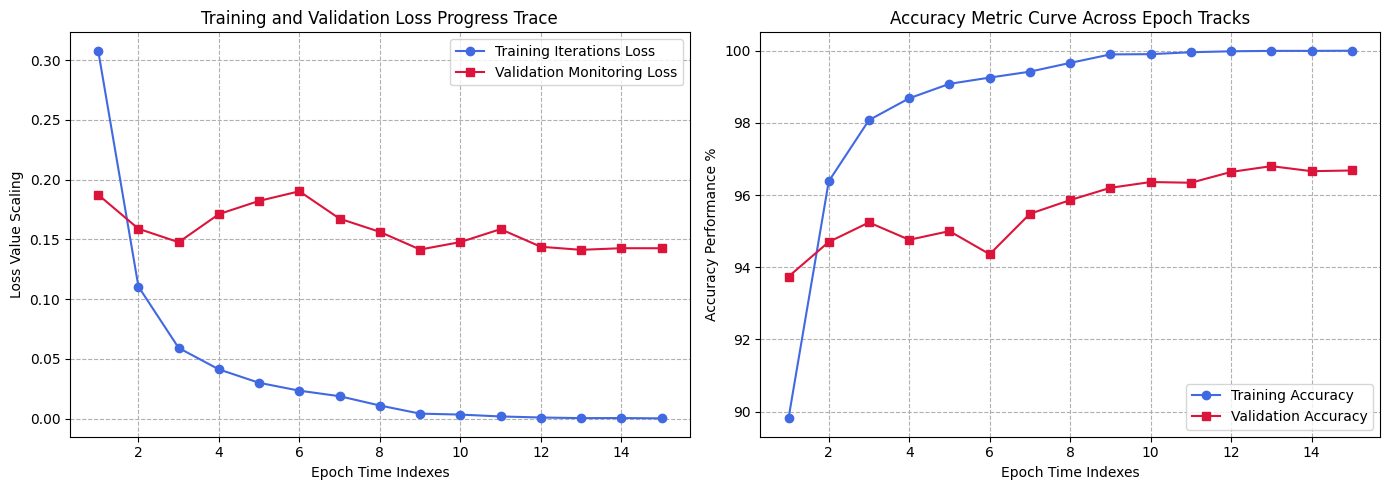

In [6]:
plt.figure(figsize=(14, 5))

# Cross Entropy Loss Performance Curve Plots
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Training Iterations Loss', marker='o', color='royalblue')
plt.plot(range(1, epochs + 1), history['val_loss'], label='Validation Monitoring Loss', marker='s', color='crimson')
plt.title('Training and Validation Loss Progress Trace')
plt.xlabel('Epoch Time Indexes')
plt.ylabel('Loss Value Scaling')
plt.grid(True, linestyle='--')
plt.legend()

# Accuracy Metric Trends Plots
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['train_acc'], label='Training Accuracy', marker='o', color='royalblue')
plt.plot(range(1, epochs + 1), history['val_acc'], label='Validation Accuracy', marker='s', color='crimson')
plt.title('Accuracy Metric Curve Across Epoch Tracks')
plt.xlabel('Epoch Time Indexes')
plt.ylabel('Accuracy Performance %')
plt.grid(True, linestyle='--')
plt.legend()

plt.tight_layout()
plt.savefig('classification_performance_curves.png', dpi=300)
plt.show()

## Step 7: Final Test Metrics Evaluation & Inference Assessment
We reload the saved high-accuracy weights check, pass down unseen test inputs, and compute critical evaluation metrics like Precision, Recall, F1 score, and a Confusion Matrix heatmap matrix breakdown.

[Inference Phase Evaluation] Loading optimal model parameters weights from directory storage pth asset track...


Final Assessment Pass: 100%|██████████| 157/157 [00:19<00:00,  7.94it/s]



===== Comprehensive Performance Analysis Classification Grid Report =====
              precision    recall  f1-score   support

    airplane     0.9654    0.9760    0.9707      1000
  automobile     0.9743    0.9850    0.9796      1000
        bird     0.9655    0.9510    0.9582      1000
         cat     0.9101    0.9210    0.9155      1000
        deer     0.9503    0.9760    0.9630      1000
         dog     0.9459    0.9090    0.9271      1000
        frog     0.9820    0.9820    0.9820      1000
       horse     0.9839    0.9790    0.9815      1000
        ship     0.9713    0.9820    0.9766      1000
       truck     0.9828    0.9700    0.9763      1000

    accuracy                         0.9631     10000
   macro avg     0.9631    0.9631    0.9630     10000
weighted avg     0.9631    0.9631    0.9630     10000

Finalized Overall Metrics: Test Accuracy: 96.31% | Macro Precision: 0.9631 | Macro Recall: 0.9631 | Macro F1-Score: 0.9630


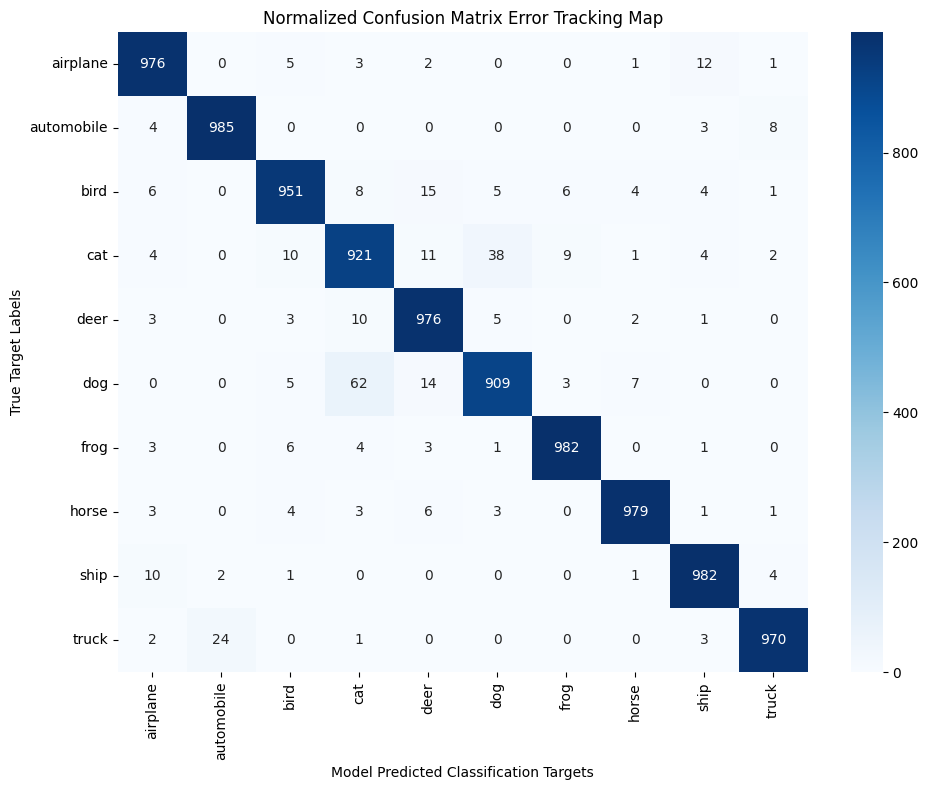

In [7]:
print("[Inference Phase Evaluation] Loading optimal model parameters weights from directory storage pth asset track...")
# Instantiate target architecture container shells structure match prior to injection
eval_model = models.resnet34()
eval_model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(eval_model.fc.in_features, len(classes))
)
eval_model.load_state_dict(torch.load('optimized_cifar10_model.pth', map_location=device))
eval_model = eval_model.to(device)
eval_model.eval()

all_predictions = []
all_ground_truths = []

with torch.no_grad():
    for test_imgs, test_labels in tqdm(test_loader, desc="Final Assessment Pass"):
        test_imgs = test_imgs.to(device)
        test_outputs = eval_model(test_imgs)
        _, test_preds = torch.max(test_outputs, 1)

        all_predictions.extend(test_preds.cpu().numpy())
        all_ground_truths.extend(test_labels.numpy())

# Compute and display a granular Classification Report metrics summary grid
print("\n===== Comprehensive Performance Analysis Classification Grid Report =====")
print(classification_report(all_ground_truths, all_predictions, target_names=classes, digits=4))

# Compute macro evaluation summary metrics indexes explicitly
p_metric, r_metric, f_metric, _ = precision_recall_fscore_support(all_ground_truths, all_predictions, average='macro')
final_test_acc = (np.array(all_predictions) == np.array(all_ground_truths)).mean() * 100

print(f"Finalized Overall Metrics: Test Accuracy: {final_test_acc:.2f}% | Macro Precision: {p_metric:.4f} | Macro Recall: {r_metric:.4f} | Macro F1-Score: {f_metric:.4f}")

# Generate and map Confusion Matrix graphical layouts
cm_data = confusion_matrix(all_ground_truths, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Normalized Confusion Matrix Error Tracking Map')
plt.ylabel('True Target Labels')
plt.xlabel('Model Predicted Classification Targets')
plt.tight_layout()
plt.savefig('error_tracking_confusion_matrix.png', dpi=300)
plt.show()